In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# High Dimensional Data Analysis


## Hypersphere Volume

In [2]:
from scipy.special import gamma

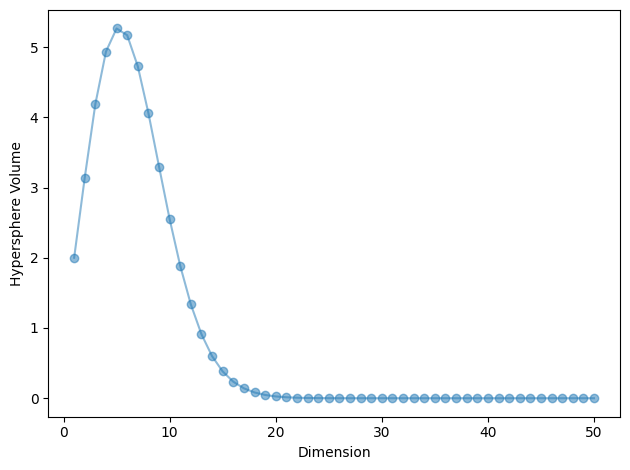

In [3]:
d = np.arange(1, 51)
sphere_volume = np.power(np.pi, d/2) / gamma(d/2 + 1)

fig, ax = plt.subplots()
ax.plot(d, sphere_volume, '-o', alpha = 0.5)
ax.set_xlabel('Dimension')
ax.set_ylabel('Hypersphere Volume')
plt.tight_layout()
plt.show()

## Hypersphere Radius

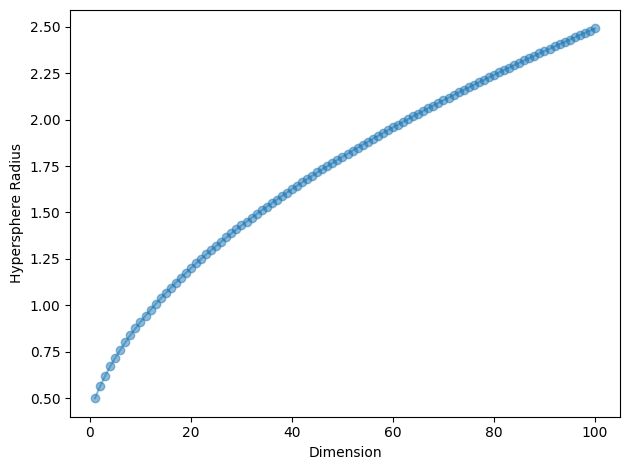

In [4]:
d = np.arange(1, 101)
sphere_volume = np.power(np.pi, d/2) / gamma(d/2 + 1)
radius = np.exp(-np.log(sphere_volume) / d)


fig, ax = plt.subplots()
ax.plot(d, radius, '-o', alpha = 0.5)
ax.set_xlabel('Dimension')
ax.set_ylabel('Hypersphere Radius')
plt.tight_layout()
plt.show()

## Nearest Neighbors

In [5]:
def process(d):
  center = np.ones(d) * 0.5
  points = np.random.uniform(size=(10000, d))

  distance = np.sqrt(((points - center) ** 2).sum(axis=1))

  nearest = distance.min()
  farthest = distance.max()
  ratio = nearest / farthest

  return nearest, farthest, ratio

In [6]:
d = np.arange(1, 101)

neighbors = np.vectorize(process)

nearest, farthest, ratio = neighbors(d)

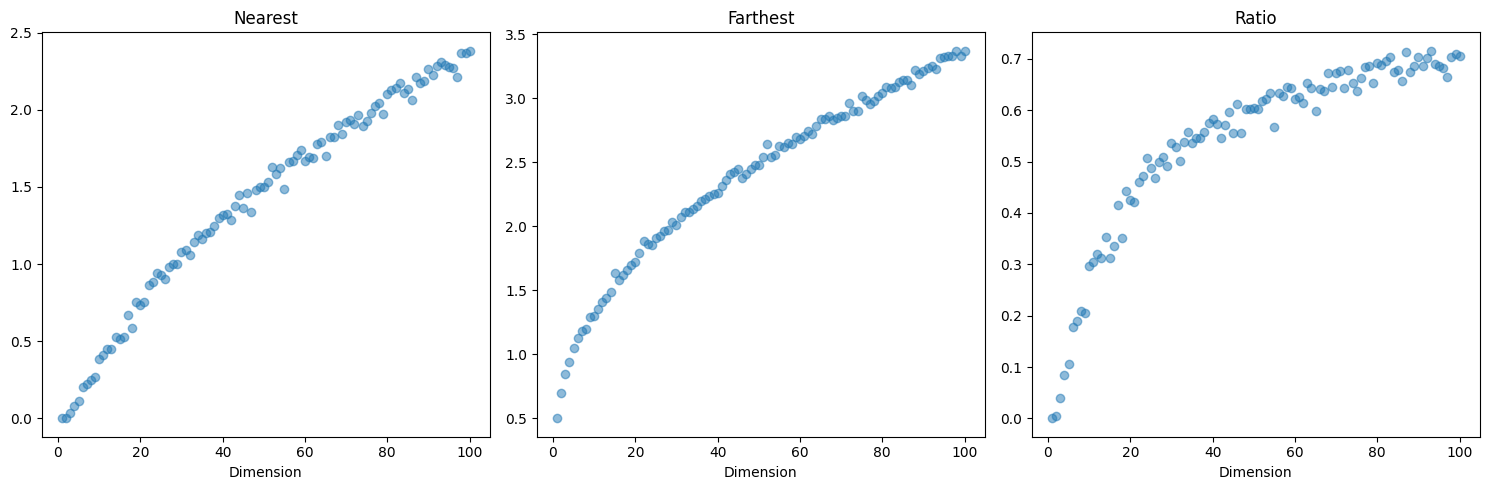

In [7]:
fig, ax = plt.subplots(1, 3, sharex=True, figsize=(15, 5))

ax[0].scatter(d, nearest, alpha=0.5)
ax[0].set(title='Nearest', xlabel='Dimension')

ax[1].scatter(d, farthest, alpha=0.5)
ax[1].set(title='Farthest', xlabel='Dimension')

ax[2].scatter(d, ratio, alpha=0.5)
ax[2].set(title='Ratio', xlabel='Dimension')

plt.tight_layout()

## Fraction of Volume


In [8]:
def inside_sphere(d):
  points = np.random.uniform(low=-1, high=1, size=(10000, d))
  distance = np.linalg.norm(points, axis=1)
  return (distance < 1).mean()

d = np.arange(1, 101)

fraction_sphere = np.vectorize(inside_sphere)

fraction = fraction_sphere(d)
fraction

array([1.000e+00, 7.832e-01, 5.306e-01, 3.069e-01, 1.629e-01, 7.870e-02,
       3.890e-02, 1.590e-02, 7.000e-03, 2.800e-03, 1.300e-03, 4.000e-04,
       1.000e-04, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 

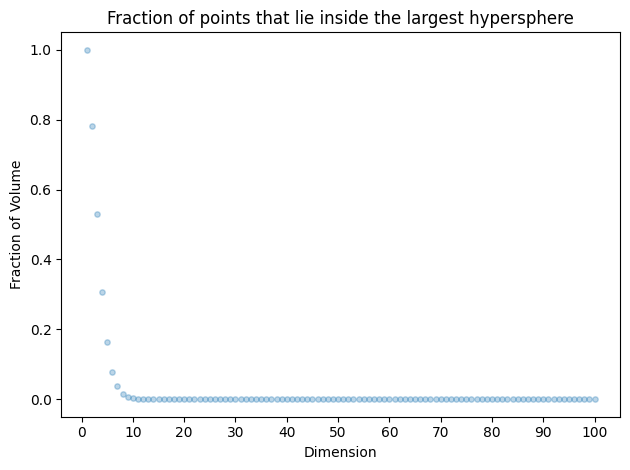

In [9]:
plt.scatter(d, fraction, alpha=0.3, s=15)
plt.xlabel('Dimension')
plt.ylabel('Fraction of Volume')
plt.title('Fraction of points that lie inside the largest hypersphere')
plt.xticks(range(0, 101, 10))
plt.tight_layout()

After dimension 10, the fraction of volume goes to essentially zero.

In [10]:
EPS = 0.01

def inside_thin_shell(d):
  points = np.random.uniform(low=-1, high=1, size=(10000, d))

  innercube = (points.max(axis=1) <= 1 - EPS) & (points.min(axis=1) >= EPS)

  return 1 - innercube.mean()

d = np.arange(1, 101)

fraction_thin_shell = np.vectorize(inside_thin_shell)

fraction = fraction_thin_shell(d)
fraction


array([0.5057, 0.7533, 0.8759, 0.9448, 0.9743, 0.9839, 0.9945, 0.996 ,
       0.9973, 0.9994, 0.9992, 1.    , 0.9997, 0.9999, 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    ])

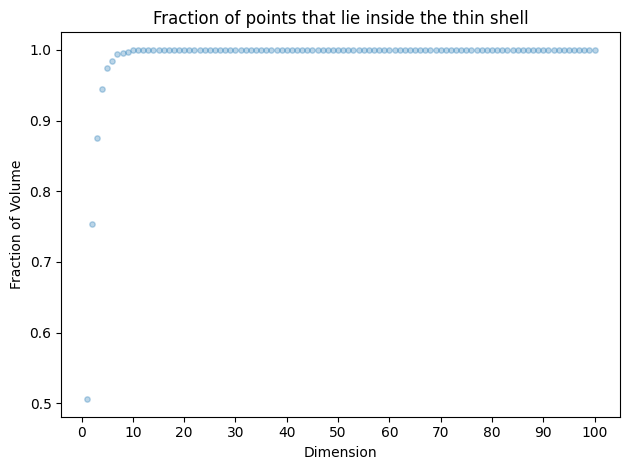

In [11]:
plt.scatter(d, fraction, alpha=0.3, s=15)
plt.xlabel('Dimension')
plt.ylabel('Fraction of Volume')
plt.title('Fraction of points that lie inside the thin shell')
plt.xticks(range(0, 101, 10))
plt.tight_layout()

The fraction of volume in the thin shell go to 100% after 13 or 14 dimensions.


# Diagonals in High Dimensions

In [12]:
def plot_angle(d):
  vec_1 = np.random.choice([-1.0, 1.0], size=(100000, d))
  vec_2 = np.random.choice([-1.0, 1.0], size=(100000, d))

  cosine = ((vec_1 * vec_2).sum(axis=1)) / (np.linalg.norm(vec_1, axis=1) * np.linalg.norm(vec_2, axis=1))

  angle = np.arccos(cosine) / np.pi * 180 # radian -> degree

  sns.histplot(x=angle, kde=True, stat='proportion')

  plt.xticks(range(30, 151, 15))
  plt.title(f'{d} Dimensions')

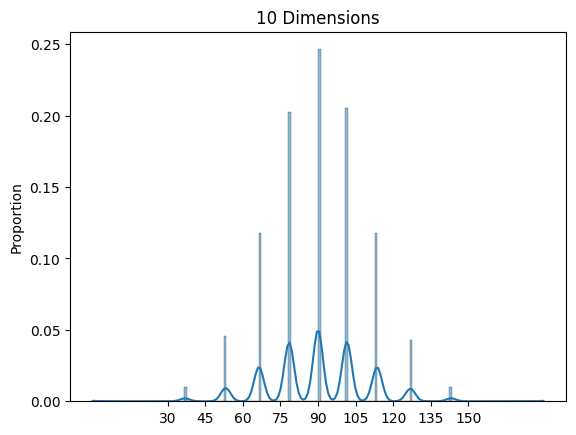

In [13]:
plot_angle(10)

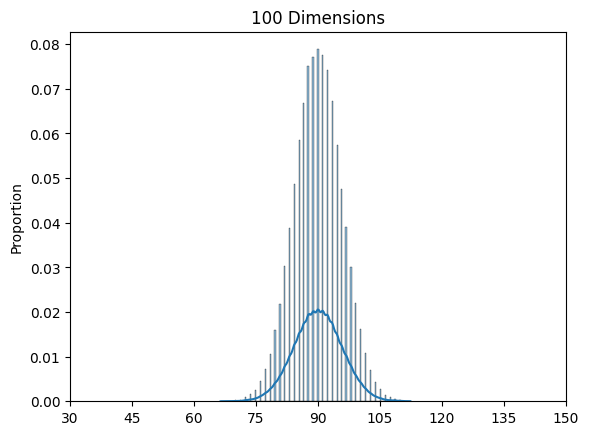

In [14]:
plot_angle(100)

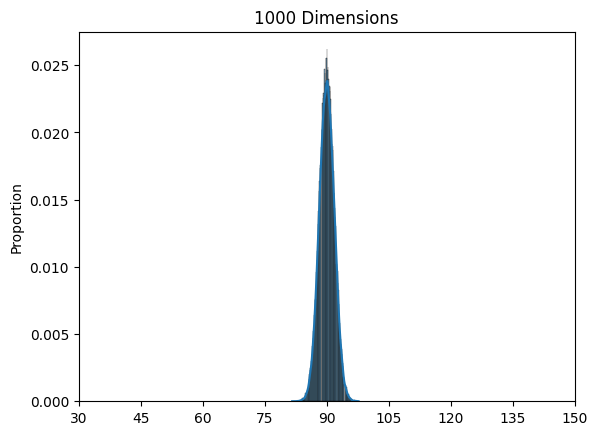

In [15]:
plot_angle(1000)